# GPU Server Shenanigans

In [1]:
import tensorflow as tf

# Check if any GPU is detected
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-02-17 15:09:53.872112: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-17 15:09:53.872138: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-17 15:09:53.872825: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-17 15:09:53.876617: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-17 15:09:54.338603: W tensorflow/compiler/tf2

Num GPUs Available:  4


2025-02-17 15:09:55.134598: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-17 15:09:55.135872: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-17 15:09:55.137142: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set TensorFlow to use only the first GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print(f"Using GPU: {gpus[0]}")
    except RuntimeError as e:
        print(e)

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Beta Object Recognition Dataset and Analysis

## Dataset Structure
- After extraction the dataset should be structured as follows:
    - data/ ├── train/ │ ├── cellphone/ │ ├── wallet/ │ ├── watch/ ├── val/ │ ├── cellphone/ │ ├── wallet/ │ ├── watch/

In [3]:
pwd

'/home/exh4748/ProjectTortoise/Beta'

In [3]:
import zipfile
import os

# Define paths
zip_path = "/home/exh4748/ProjectTortoise/ObjectData/data2.zip"
extract_to = "/home/exh4748/ProjectTortoise/ObjectData/"

# Creating directory if it doesn't exist
os.makedirs(extract_to, exist_ok = True)

# Extract the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Dataset extracted to {extract_to}")

Dataset extracted to /home/exh4748/ProjectTortoise/ObjectData/


In [4]:
import shutil
import random
import os

# Paths
base_dir = "/home/exh4748/ProjectTortoise/ObjectData/data2"
test_dir = os.path.join(base_dir, "test")
categories = ["cellphone", "wallet", "watch"]
test_ratio = 0.2  # Percentage of data for the test set

# Create test directories
os.makedirs(test_dir, exist_ok=True)
for category in categories:
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

# Move a subset of images to the test directory
for category in categories:
    train_path = os.path.join(base_dir, "train", category)
    val_path = os.path.join(base_dir, "val", category)
    test_path = os.path.join(test_dir, category)
    
    # Combine train and val images
    all_images = os.listdir(train_path) + os.listdir(val_path)
    
    # Shuffle and split for test set
    random.shuffle(all_images)
    test_images = all_images[:int(len(all_images) * test_ratio)]
    
    # Move test images
    for img in test_images:
        src = os.path.join(train_path if img in os.listdir(train_path) else val_path, img)
        dest = os.path.join(test_path, img)
        shutil.move(src, dest)

print(f"Test set created at {test_dir}")

Test set created at /home/exh4748/ProjectTortoise/ObjectData/data2/test


# Basic Exploratory Data Analysis (EDA)

## Visualizing Dataset Distribution

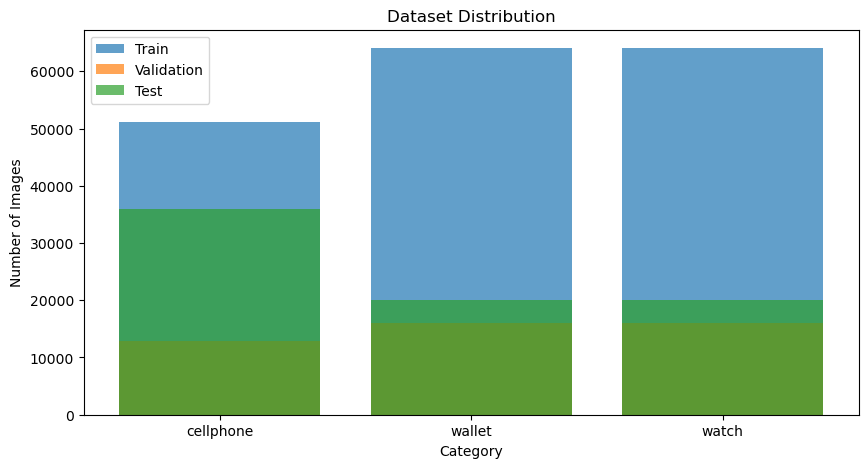

In [14]:
import matplotlib.pyplot as plt

# Count the number of images in each category
def count_images(folder_path):
    counts = {}
    for category in categories:
        category_path = os.path.join(folder_path, category)
        counts[category] = len(os.listdir(category_path))
    return counts

train_counts = count_images(os.path.join(base_dir, "train"))
val_counts = count_images(os.path.join(base_dir, "val"))
test_counts = count_images(test_dir)

# Plot the distribution
plt.figure(figsize=(10, 5))
for dataset, counts in [("Train", train_counts), ("Validation", val_counts), ("Test", test_counts)]:
    plt.bar(counts.keys(), counts.values(), alpha=0.7, label=dataset)
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.legend()
plt.show()

# Visualizing Sample Images from Each Category

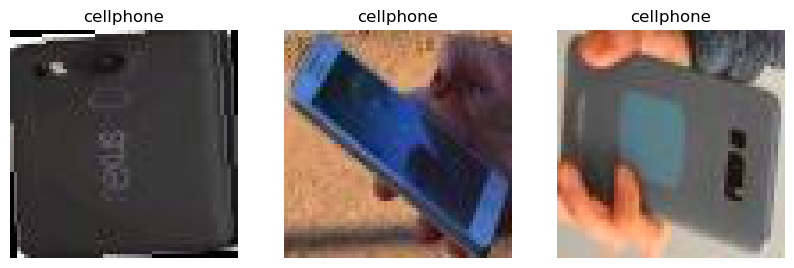

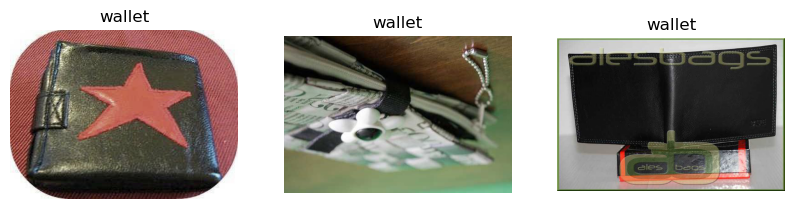

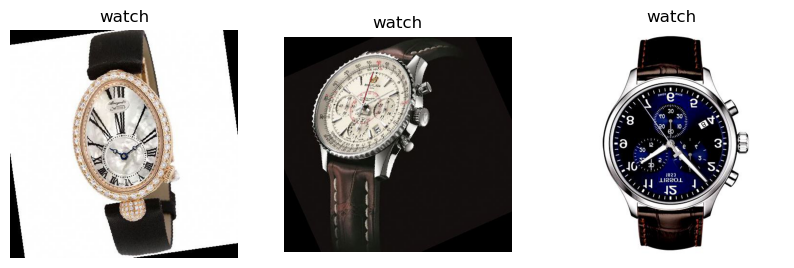

In [15]:
from matplotlib.image import imread

# Display a few sample images
def display_samples(folder_path, category, n=3):
    category_path = os.path.join(folder_path, category)
    sample_images = random.sample(os.listdir(category_path), n)
    
    plt.figure(figsize=(10, 5))
    for i, img_name in enumerate(sample_images):
        img = imread(os.path.join(category_path, img_name))
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)
    plt.show()

# Show samples
for category in categories:
    display_samples(os.path.join(base_dir, "train"), category)

# Category-Wise Image Size Distribution

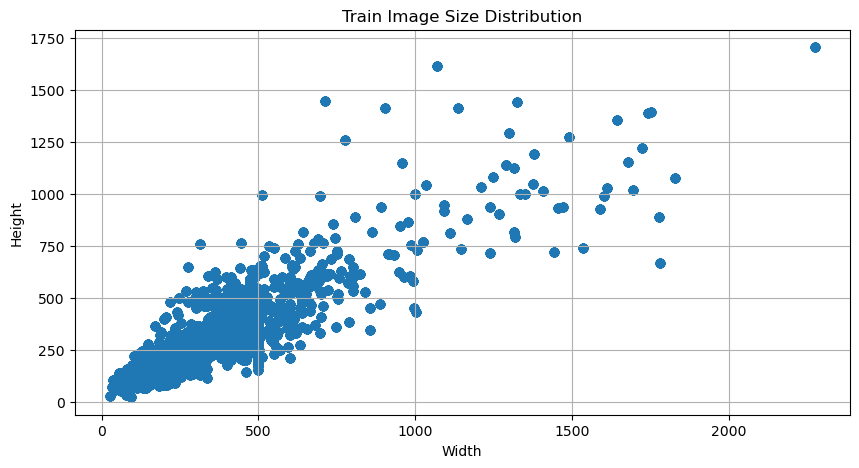

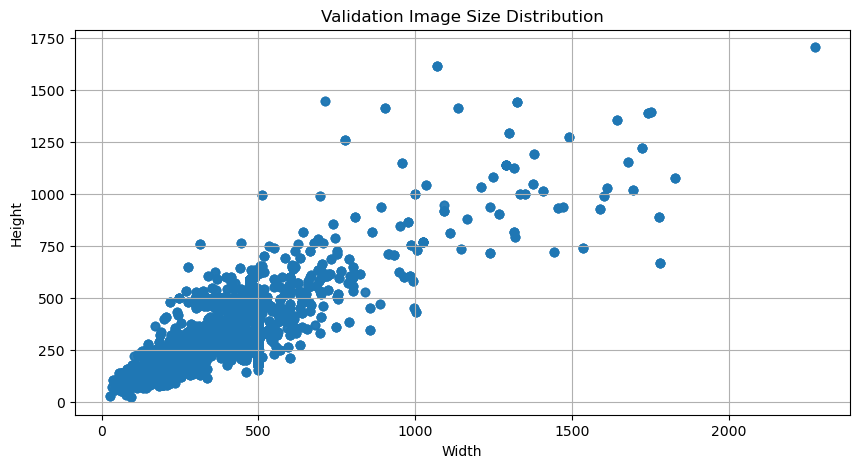

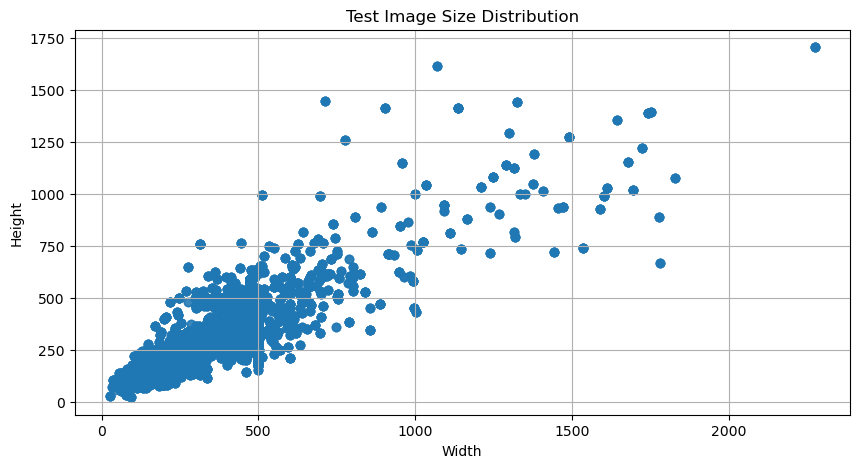

In [16]:
from PIL import Image
import numpy as np

# Analyze image sizes
def get_image_sizes(folder_path):
    sizes = []
    for category in categories:
        category_path = os.path.join(folder_path, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            with Image.open(img_path) as img:
                sizes.append(img.size)
    return sizes

# Collect size data
train_sizes = get_image_sizes(os.path.join(base_dir, "train"))
val_sizes = get_image_sizes(os.path.join(base_dir, "val"))
test_sizes = get_image_sizes(test_dir)

# Plot image size distributions
def plot_image_size_distribution(sizes, title):
    widths, heights = zip(*sizes)
    plt.figure(figsize=(10, 5))
    plt.scatter(widths, heights, alpha=0.5)
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_image_size_distribution(train_sizes, "Train Image Size Distribution")
plot_image_size_distribution(val_sizes, "Validation Image Size Distribution")
plot_image_size_distribution(test_sizes, "Test Image Size Distribution")

# Corrupt/Missing Images

In [17]:
def check_corrupt_images(folder_path):
    corrupt_images = []
    for category in categories:
        category_path = os.path.join(folder_path, category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image is not corrupt
            except (IOError, SyntaxError):
                corrupt_images.append(img_path)
    return corrupt_images

# Check for corrupt images
corrupt_train_images = check_corrupt_images(os.path.join(base_dir, "train"))
corrupt_val_images = check_corrupt_images(os.path.join(base_dir, "val"))
corrupt_test_images = check_corrupt_images(test_dir)

print("Corrupt Images:")
print(f"Train: {corrupt_train_images}")
print(f"Validation: {corrupt_val_images}")
print(f"Test: {corrupt_test_images}")


Corrupt Images:
Train: []
Validation: []
Test: []
